# A short story through esTS

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SergeyShk/esTS/blob/master/examples/01_text_walkthrough.ipynb)

One complete short story, *El almohadón de pluma* by Horacio Quiroga (1917), goes through esTS tool by tool: the extractors, syllables and stress, the basic, readability, diversity, morphological, syntactic, cohesion, lexical, style and sound statistics, the highlighting, the plots and the corpus measures; a sonnet stands in for the story in the verse statistics. At the end the spaCy components of the library process all the stories of the same book into one table. Every section links to the page of the [documentation](https://sergeyshk.github.io/esTS/) with all the statistics and parameters.

## Installation

In Colab the cell installs the library and the spaCy model `es_core_news_sm`; where they are installed it does nothing.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("ests") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyests"], check=True)
if importlib.util.find_spec("es_core_news_sm") is None:
    subprocess.run(
        [sys.executable, "-m", "spacy", "download", "es_core_news_sm", "-q"], check=True
    )

## The text

The story comes from the [corpus of Spanish-language literature](https://sergeyshk.github.io/esTS/datasets/spanishliterature/), where *Cuentos de amor de locura y de muerte* (1917) by the Uruguayan writer Horacio Quiroga is one record, the transcription of [Project Gutenberg](https://www.gutenberg.org). The stories of the book open with their titles on lines of capitals, so the book is cut at these lines. The story of this notebook is printed in the edition as *EL ALMOHADON DE PLUMA* and is known today mostly as *El almohadón de plumas*; the text keeps the spelling of the edition (`fué`, `dió`), its dialogue dashes typed as `--` and its hard-wrapped lines.

In [2]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import spacy
from IPython.display import HTML
from spacy.lang.es.stop_words import STOP_WORDS

from ests import (
    BasicStats,
    CharNgramsExtractor,
    CohesionStats,
    DiversityStats,
    LexicalStats,
    MorphStats,
    PhonStats,
    ReadabilityStats,
    SentsExtractor,
    StyleStats,
    SyntaxStats,
    VerseStats,
    WordsExtractor,
)
from ests.basic_stats import punctuation_profile
from ests.corpus import collocations, kwic, print_kwic
from ests.datasets import FreqDict, SpanishLiterature, SpanishSonnets
from ests.diversity_stats import fit_zipf_mandelbrot
from ests.syllables import count_syllables, stress_type, syllabify, word_stress, word_stresses
from ests.utils import get_nlp
from ests.visualizers import highlight, sentence_lengths, sentence_lengths_plot, zipf

sl = SpanishLiterature()
sl.download()
record = next(sl.get_records(author="quiroga"))
book = record["text"].strip().removesuffix("FIN")

# A title is a line of capitals; the parts II and III of the first story are too short to match
titles = list(re.finditer(r"(?m)^[A-ZÁÉÍÓÚÑÜ][A-ZÁÉÍÓÚÑÜ ,.]{4,}$", book))
ends = [title.start() for title in titles[1:]] + [len(book)]
stories = {
    title.group().capitalize(): book[title.end() : end].strip()
    for title, end in zip(titles, ends, strict=True)
}
text = stories["El almohadon de pluma"]

print(record["author"], "-", record["title"], record["year_from"], "-", record["country"])
print(len(stories), "stories:", ", ".join(stories))

Horacio Quiroga - Cuentos de amor de locura y de muerte 1917 - Uruguay
18 stories: Una estacion de amor, Los ojos sombrios, El solitario, La muerte de isolda, El infierno artificial, La gallina degollada, Los buques suicidantes, El almohadon de pluma, El perro rabioso, A la deriva, La insolacion, El alambre de pua, Los mensú, Yaguaí, Los pescadores de vigas, La miel silvestre, Nuestro primer cigarro, La meningitis y su sombra


In [3]:
sentences = SentsExtractor().extract(text)
words = WordsExtractor().extract(text)
paragraphs = text.split("\n\n")
print(
    f"{len(text)} characters, {len(paragraphs)} paragraphs, "
    f"{len(sentences)} sentences, {len(words)} words\n"
)
print(paragraphs[0])

7210 characters, 30 paragraphs, 86 sentences, 1216 words

Su luna de miel fué un largo escalofrío. Rubia, angelical y tímida, el
carácter duro de su marido heló sus soñadas niñerías de novia. Lo
quería mucho, sin embargo, a veces con un ligero estremecimiento
cuando volviendo de noche juntos por la calle, echaba una furtiva
mirada a la alta estatura de Jordán, mudo desde hacía una hora. El,
por su parte, la amaba profundamente, sin darlo a conocer.


The book holds 18 stories, and *El almohadon de pluma* is the eighth of them. The story has 7210 characters in 30 paragraphs: 86 sentences and 1216 words by the default extractors of the next section. The first paragraph shows the edition: the old accent of `fué`, the pronoun `El` written without its accent as a capital and the lines broken in the middle of the sentences.

## Extraction

[`SentsExtractor`](https://sergeyshk.github.io/esTS/extractors/sentences/) splits a text by rules: a single line break does not end a sentence, and a dash before a lower-case word opens a remark of the narrator and keeps the sentence going. [`WordsExtractor`](https://sergeyshk.github.io/esTS/extractors/words/) takes the words of the spaCy Spanish tokenizer, splits off the dashes glued to them and can lemmatize them, drop stop words and count the most frequent ones. [`CharNgramsExtractor`](https://sergeyshk.github.io/esTS/extractors/char_ngrams/) cuts the text into sequences of characters.

In [4]:
dialogue = [sent for sent in sentences if sent.startswith("--")]
print(len(dialogue), "sentences open with a dash of dialogue\n")
for sent in [*sentences[:2], *dialogue[:4]]:
    print(" ".join(sent.split()))

10 sentences open with a dash of dialogue

Su luna de miel fué un largo escalofrío.
Rubia, angelical y tímida, el carácter duro de su marido heló sus soñadas niñerías de novia.
--No sé--le dijo a Jordán en la puerta de calle, con la voz todavía baja.--Tiene una gran debilidad que no me explico, y sin vómitos, nada...
--¡Jordán!
--¡Soy yo, Alicia, soy yo!
--Pst...--se encogió de hombros desalentado su médico.--Es un caso serio... poco hay que hacer...


The hard-wrapped lines do not split the sentences, and in `--No sé--le dijo a Jordán` the dash before the lower-case `le` keeps the remark of the narrator inside the sentence; ten sentences open with a dash. Where the edition glues the dash to a period (`baja.--Tiene`, `médico.--Es`) the rules see no space after the period, so twice two lines of the doctor stay one sentence, and the count of 86 misses these two boundaries.

In [5]:
ce = CharNgramsExtractor(n=3, lowercase=True, within_words=True)
print(len(ce.extract(text)), "trigrams inside the words, the most frequent:")
print(ce.get_most_common(10))
we = WordsExtractor(use_lexemes=True, lowercase=True, filter_nums=True, stopwords=STOP_WORDS)
lemmas = we.extract(text)
print(len(lemmas), "lemmas without the stop words of spaCy, the most frequent:")
pd.DataFrame(we.get_most_common(12), columns=["lemma", "count"])

3349 trigrams inside the words, the most frequent:
[('ent', 43), ('que', 33), ('nte', 32), ('con', 25), ('aba', 25), ('men', 23), ('des', 22), ('cia', 22), ('ndo', 21), ('lic', 20)]


549 lemmas without the stop words of spaCy, the most frequent:


,lemma,count
0,jordán,16
1,alicia,16
2,mirar,10
3,cama,8
4,rato,7
5,noche,6
6,hora,5
7,alfombra,5
8,sangre,5
9,almohadón,5


Without the stop words 549 lemmas remain, and the two characters lead them: `jordán` and `alicia` 16 times each, then `mirar` (10), `cama` (8) and `rato` (7), with `sangre`, `almohadón` and `alfombra` 5 times each - the plot in a dozen words. `fué` (4) is there because the stop list of spaCy knows only the modern `fue`, and simplemma maps `sirvienta` to `sirviente`. Among the character trigrams `lic` comes from Alicia, `que` mostly from the word `que`, `aba` and `ndo` mostly from the endings of the imperfect and of the gerund.

## Syllables and stress

The module [`ests.syllables`](https://sergeyshk.github.io/esTS/syllables/) divides a word into syllables and finds its stress from the spelling alone, by the rules of the *Ortografía* of the RAE. The words below are taken from the story; then the stress types are counted over all its words of more than one syllable.

In [6]:
sample = [
    "almohadón",
    "escalofrío",
    "ahogaba",
    "antropoide",
    "agudísima",
    "Paseábase",
    "Levántelo",
    "desmesuradamente",
    "aún",
    "fué",
    "Pst",
]
pd.DataFrame(
    [
        {
            "word": word,
            "syllables": "-".join(syllabify(word)),
            "count": count_syllables(word),
            "stress": word_stress(word),
            "all stresses": word_stresses(word),
            "type": stress_type(word),
        }
        for word in sample
    ]
).set_index("word").astype({"stress": "Int64"})

,syllables,count,stress,all stresses,type
word,,,,,
almohadón,al-mo-ha-dón,4,3,[3],aguda
escalofrío,es-ca-lo-frí-o,5,3,[3],llana
ahogaba,a-ho-ga-ba,4,2,[2],llana
antropoide,an-tro-poi-de,4,2,[2],llana
agudísima,a-gu-dí-si-ma,5,2,[2],esdrújula
Paseábase,pa-se-á-ba-se,5,2,[2],esdrújula
Levántelo,le-ván-te-lo,4,1,[1],esdrújula
desmesuradamente,des-me-su-ra-da-men-te,7,5,"[3, 5]",llana
aún,a-ún,2,1,[1],aguda


In [7]:
types = pd.Series([stress_type(word) for word in words if count_syllables(word) > 1])
pd.DataFrame({"words": types.value_counts(), "share": types.value_counts(normalize=True).round(2)})

,words,share
llana,559,0.77
aguda,137,0.19
esdrújula,29,0.04


The `h` between vowels does not break the syllables of `al-mo-ha-dón`, the accented `í` makes a hiatus in `es-ca-lo-frí-o`, and `oi` is a diphthong in `an-tro-poi-de`. The forms with enclitic pronouns keep their stress (`Pa-se-á-ba-se`, `Le-ván-te-lo`: esdrújulas), `desmesuradamente` has two stresses, one of the adjective and one of `-mente`, and the old `fué` is a monosyllable. The interjection `Pst` has no vowel, hence no syllables and no stress. Among the 725 words of more than one syllable the llanas lead with 559 (77%), the agudas follow with 137 (19%) and the esdrújulas are 29 (4%).

## Basic statistics

[`BasicStats`](https://sergeyshk.github.io/esTS/stats/basic_stats/) counts the sentences, words, syllables and letters of the text and the long (seven letters or more), complex (three syllables or more), monosyllabic and polysyllabic words. The [punctuation profile](https://sergeyshk.github.io/esTS/stats/basic_stats/#punctuation) gives the marks per 1000 words and the share of the inverted `¿` and `¡` among the question and exclamation marks.

In [8]:
bs = BasicStats(text, normalize=True)
print(f"{bs.n_sents} sentences, {bs.n_words} words, {bs.n_syllables} syllables")
print(
    f"{bs.n_words / bs.n_sents:.2f} words per sentence, "
    f"{bs.n_syllables / bs.n_words:.2f} syllables per word"
)
kinds = ["unique", "long", "complex", "simple", "monosyllable", "polysyllable"]
pd.DataFrame(
    {
        "count": [getattr(bs, f"n_{kind}_words") for kind in kinds],
        "share": [getattr(bs, f"p_{kind}_words") for kind in kinds],
    },
    index=kinds,
).round(2)

86 sentences, 1216 words, 2497 syllables
14.14 words per sentence, 2.05 syllables per word


,count,share
unique,549,0.45
long,290,0.24
complex,361,0.30
simple,854,0.70
monosyllable,490,0.40
polysyllable,725,0.60


In [9]:
profile = punctuation_profile(text)
print("Share of the inverted marks:", profile.pop("inverted_share"))
pd.DataFrame({"count": bs.c_punctuations, "per 1000 words": profile}).query("count > 0").round(2)

Share of the inverted marks: 0.5


,count,per 1000 words
comma,99,81.41
period,85,69.90
question,2,1.64
exclamation,8,6.58
ellipsis,4,3.29
colon,1,0.82
semicolon,3,2.47
dash,29,23.85


A sentence has 14.14 words on average and a word 2.05 syllables; 40% of the words are monosyllables and 30% have three syllables or more, and 45% of the word forms are distinct. The commas (99) and the periods (85) lead the marks, and the dashes come third with 29 - the dialogue dashes typed as `--`, counted as dashes and not as hyphens. The share of the inverted marks is 0.5, the value of a text where every question and exclamation opens with `¿` or `¡`.

## Readability

[`ReadabilityStats`](https://sergeyshk.github.io/esTS/stats/readability_stats/) takes the basic statistics computed above instead of counting the text again. The reading ease of Szigriszt-Pazos (the `general` preset) is read on the INFLESZ scale, the consensus grade and the Crawford grade as a stage of the Spanish school system; the `classic` preset gives the reading ease of Fernández Huerta.

In [10]:
rs = ReadabilityStats(bs)
display(pd.Series(rs.get_stats(), name="value").round(2).to_frame())
print("Reading ease (INFLESZ):", rs.describe_level())
print("Legibilidad µ:", rs.describe_level("mu_index"))
print("Consensus grade:", rs.describe_grade())
print("Crawford grade:", rs.describe_grade("crawford_grade"))
aloud, silently = rs.reading_time_by_norm("grade_6")
print(f"Reading time in grade 6: {aloud:.1f} min aloud, {silently:.1f} min silently")
classic = ReadabilityStats(bs, preset="classic")
print(f"Fernández Huerta: {classic.flesch_reading_easy:.2f} ({classic.describe_level()})")

,value
flesch_reading_easy,64.77
gutierrez_polini_index,44.65
crawford_grade,5.21
mu_index,58.52
sol_grade,8.47
lix,37.99
rix,3.37
consensus_grade,8.00
reading_time,4.37


Reading ease (INFLESZ): normal
Legibilidad µ: un poco difícil
Consensus grade: ESO (12-16 years)
Crawford grade: primary school, grades 4-6 (9-12 years)
Reading time in grade 6: 9.8 min aloud, 7.8 min silently
Fernández Huerta: 69.21 (normal)


The reading ease of 64.77 is `normal` on the INFLESZ scale, just below the band `bastante fácil` that starts at 65, and Fernández Huerta gives 69.21, `normal` on its own scale. Legibilidad µ is stricter (58.52, `un poco difícil`). Crawford (5.21) places the text in primary school, grades 4-6, while the consensus grade of 8 - the median of Crawford, SOL (8.47) and the reading ease - places it in ESO. An adult reads the story silently in 4.37 minutes at 278 words per minute, a sixth-grader in 7.8.

## Lexical diversity

[`DiversityStats`](https://sergeyshk.github.io/esTS/stats/diversity_stats/) counts how varied the words are; the words are lower-cased, and the metrics differ in how much they depend on the length of the text. The [windowed computation](https://sergeyshk.github.io/esTS/stats/diversity_stats/#windowed) gives a metric over windows of equal length with a confidence interval, the way to compare texts of different lengths.

In [11]:
ds = DiversityStats(text)
stats = ds.get_stats()
chosen = ["ttr", "mattr", "msttr", "mtld", "hdd", "yule_k", "hapax_ratio", "entropy"]
display(pd.Series({name: stats[name] for name in chosen}, name="value").round(3).to_frame())
window = ds.windowed("ttr", window_len=100)
print(
    f"TTR over {window.n_windows} windows of 100 words: {window.mean:.3f} "
    f"(95% interval {window.lower:.3f}-{window.upper:.3f})"
)

,value
ttr,0.451
mattr,0.832
msttr,0.838
mtld,108.807
hdd,0.854
yule_k,101.795
hapax_ratio,0.740
entropy,7.976


TTR over 12 windows of 100 words: 0.744 (95% interval 0.713-0.775)


The TTR of the whole story is 0.451, but over windows of 100 words it is 0.744 (0.713-0.775 over 12 windows): the plain ratio falls as a text grows and says little alone. The metrics built to resist the length agree with each other: MATTR 0.832 and MSTTR 0.838 over windows of 50 words, HD-D 0.854, MTLD 108.8 words per factor. Three quarters of the lexemes are hapaxes (0.74).

## Morphology

From here on the statistics need the annotation of a model, so the story is parsed once with `es_core_news_sm` by `get_nlp` (the model with the rules for the dialogue dashes), and the `Doc` is used by all the following sections. [`MorphStats`](https://sergeyshk.github.io/esTS/stats/morph_stats/) counts the parts of speech and the features of Universal Dependencies and computes the markers of Spanish.

In [12]:
nlp = get_nlp()
doc = nlp(text)
ms = MorphStats(doc)
pos = pd.Series(ms.get_stats("pos")["pos"]).sort_values(ascending=False)
display(pos.to_frame("words").T)
print(ms.get_stats("tense", "mood", "verb_form", filter_none=True))
pd.Series(ms.get_markers(), name="share").round(2).to_frame()

,NOUN,ADP,DET,VERB,ADJ,ADV,PRON,PROPN,CCONJ,AUX,SCONJ,NUM,PART,INTJ
words,272,199,180,165,103,76,73,46,42,34,17,7,1,1


{'tense': {'Imp': 60, 'Past': 71, 'Pres': 22}, 'mood': {'Ind': 140, 'Sub': 4}, 'verb_form': {'Fin': 144, 'Part': 38, 'Ger': 15, 'Inf': 31}}


,share
p_indicative,0.97
p_subjunctive,0.03
p_conditional,0.00
p_imperative,0.00
p_infinitive,0.16
p_gerund,0.08
p_participle,0.05
p_ser,0.70
p_mente_adverbs,0.24


Nouns lead (272), then the prepositions and the determiners, and the verbs come fourth with 165. The tenses are the ones of a narration: 71 forms of the preterite (`Past`) and 60 of the imperfect (`Imp`) against 22 of the present. The indicative takes 97% of the finite forms and the subjunctive 3%; the imperative is 0, although the doctor and Jordán give orders (`llámeme`, `Levántelo`) - the model misreads the verbs with enclitic pronouns, as the documentation warns. `ser` takes 70% of the copulas, and 24% of the adverbs end in `-mente`.

## Syntax and cohesion

[`SyntaxStats`](https://sergeyshk.github.io/esTS/stats/syntax_stats/) measures the dependency tree: the distances between the words and their heads, the depth of the tree, the clauses and the constructions of the administrative style. [`CohesionStats`](https://sergeyshk.github.io/esTS/stats/cohesion_stats/) measures how the sentences hold together in the manner of [Coh-Metrix](https://doi.org/10.1017/CBO9780511894664): the overlap of their nouns, arguments and content words, the words seen before, the repetition of tense and mood and the connectors.

In [13]:
ss = SyntaxStats(doc)
chosen = [
    "mean_dependency_distance",
    "tree_depth",
    "clauses_per_sent",
    "mean_clause_len",
    "subordinate_clauses_per_sent",
    "p_complex_sents",
    "coordination_chains_per_sent",
    "gerund_clauses_per_sent",
    "p_passive",
    "negations_per_sent",
    "noun_verb_ratio",
]
print("Split predicates:", ss.split_predicates)
pd.Series({name: getattr(ss, name) for name in chosen}, name="value").round(2).to_frame()

Split predicates: ('Tuvo ataque', 'tener alucinaciones', 'hacer caso')


,value
mean_dependency_distance,2.37
tree_depth,3.75
clauses_per_sent,1.89
mean_clause_len,7.65
subordinate_clauses_per_sent,0.65
p_complex_sents,0.44
coordination_chains_per_sent,0.49
gerund_clauses_per_sent,0.11
p_passive,0.03
negations_per_sent,0.20


In [14]:
cs = CohesionStats(doc)
chosen = [
    "noun_overlap_adjacent",
    "argument_overlap_adjacent",
    "content_overlap_adjacent",
    "p_given",
    "tense_repetition",
    "mood_repetition",
    "connectors",
    "connectors_additive",
    "connectors_temporal",
    "connectors_adversative",
    "connectors_causal",
]
print(cs.n_connectors, "connectors, the most frequent:", Counter(cs.c_connectors).most_common(6))
pd.Series({name: getattr(cs, name) for name in chosen}, name="value").round(2).to_frame()

70 connectors, the most frequent: [('y', 32), ('pero', 6), ('en seguida', 4), ('luego', 3), ('apenas', 2), ('desde que', 2)]


,value
noun_overlap_adjacent,0.08
argument_overlap_adjacent,0.24
content_overlap_adjacent,0.13
p_given,0.36
tense_repetition,0.52
mood_repetition,0.97
connectors,57.57
connectors_additive,31.25
connectors_temporal,15.62
connectors_adversative,7.40


The mean dependency distance is 2.37 words, a sentence has 1.89 clauses of 7.65 words, and 44% of the sentences have a subordinate clause. The passive is almost absent (3% of the verb forms), and of the three split predicates only `tener alucinaciones` and `Tuvo ataque` are real ones - `hacer caso` joins `caso` of `Es un caso serio` with the `hacer` of `poco hay que hacer`. The adjacent sentences share a noun in only 8% of the pairs and an argument, a noun or a pronoun, in 24%: the pronouns triple the overlap, so the sentences are linked by pronouns more than by repeated nouns. Of the 70 connectors 32 are `y`, and there is no causal one at all.

## Lexical sophistication

[`LexicalStats`](https://sergeyshk.github.io/esTS/stats/lexical_stats/) compares the words with their frequencies in the language: the [frequency dictionary](https://sergeyshk.github.io/esTS/datasets/freqdict/) of [Google Books Ngram](https://storage.googleapis.com/books/ngrams/books/datasetsv3.html) (downloaded once) and the embedded list of its 10000 most frequent lemmas.

In [15]:
fd = FreqDict()
fd.download()
ls = LexicalStats(doc, freq_dict=fd)
display(pd.Series(ls.get_stats(), name="value").round(3).to_frame())
rare = {word.lower() for word, rank in zip(ls.words, ls.ranks, strict=True) if rank is None}
print(len(rare), "word forms with a lemma beyond the top 10000:")
print(", ".join(sorted(rare)))

,value
coverage,0.998
mean_ipm,17405.303
mean_ipm_content,445.418
mean_log_ipm,2.932
mean_log_ipm_content,1.809
mean_range,40.000
mean_dispersion,97.548
surprisal,10.226
perplexity,1197.284
p_top1000,0.696


74 word forms with a lemma beyond the top 10000:
adelgazara, agónico, alarido, alicia, almohadones, almohadón, angelical, antropoide, bandós, blancura, colcha, constatóse, crepusculares, crispadas, darlo, deliró, desalentado, desangrándose, desapacible, desmayos, desmesuradamente, dificultosamente, dormitaba, envoltura, erizaban, estremecimiento, estremecimientos, estuco, estupefacta, estupor, extravío, frisos, furtiva, fúnebremente, glacial, heló, hundimiento, impasible, imperceptible, incauta, influenza, insidiosamente, inútilmente, jordán, levántelo, lívida, niñerías, obstinación, oir, ordenándole, otoñal, pasábanse, perdió, perlaron, picadura, picaduras, porfiadas, pst, rasguño, redoblando, resopló, sensibilizado, serenó, serles, sigilosamente, subdelirio, succión, síncope, tamborileó, trompa, vaciado, velludas, viscosa, visiblemente


The dictionary covers 99.8% of the words, and 69.6% of them have a lemma of the 1000 most frequent ones; 8.9% lie beyond the top 10000. These 74 forms are mostly of three kinds: the vocabulary of the story (`antropoide`, `velludas`, `viscosa`, `succión`, `síncope`, `estupor`), the names `alicia` and `jordán`, and forms that the lemmatizer does not reduce - the enclitic pronouns of `levántelo`, `pasábanse`, `constatóse` and the old spelling of `oir`.

## Style and sounds

[`StyleStats`](https://sergeyshk.github.io/esTS/stats/style_stats/) computes the indicators of the SEO services - nausea, water, spam, the naturalness by Zipf's law - and the markers of the officialese style. [`PhonStats`](https://sergeyshk.github.io/esTS/stats/phon_stats/) counts the sounds of the transcription of the words: the classes of the sounds, the syllables, the consonant clusters and the indices of alliteration and assonance.

In [16]:
style = StyleStats(doc)
display(pd.Series(style.get_stats(), name="value").round(2).to_frame())
ps = PhonStats(doc)
pd.Series(ps.get_stats(), name="value").round(3).to_frame()

,value
classic_nausea,7.87
academic_nausea,26.81
water,44.08
spam,54.85
zipf_naturalness,0.00
verbal_nouns,9.56
compound_prepositions,0.00
parentheticals,0.33
cliches,0.00


,value
p_vowels,0.475
p_sonorants,0.229
p_voiced,0.101
p_voiceless,0.196
consonant_vowel_ratio,1.106
p_heavy_clusters,0.021
p_hiatus,0.055
cv_entropy,5.348
hardness,0.278
alliteration,0.938


The markers of the officialese style are empty - no compound preposition, no cliché - and only 9.56% of the nouns are verbal nouns. The SEO indicators are off their norms, which are set for web texts: the classic nausea of 7.87 means that the most frequent word form occurs 62 times, the naturalness by Zipf's law is clipped to 0, and the water (44%) is high for the norm of Text.ru, set for Russian, a language without articles. Among the sounds the vowels take 47.5%, 69.2% of the syllables are open and the hardness is 0.278. The indices of alliteration (0.938) and assonance (1.008) are close to 1, the value of repetitions spread at random: over a whole text of prose the repetitions of sounds do not gather.

## Verse

[`VerseStats`](https://sergeyshk.github.io/esTS/stats/verse_stats/) scans verse, so a poem takes the place of the story here: from the [Spanish sonnets](https://sergeyshk.github.io/esTS/datasets/spanishsonnets/) of the [DISCO](https://github.com/pruizf/disco) corpus, *El vampiro* by Delmira Agustini, a Uruguayan poet of Quiroga's time on the motif of the story, a love that drinks blood. The text is the one of DISCO, whose lines lack some of their punctuation.

In [17]:
sonnets = SpanishSonnets()
sonnets.download()
poem = next(
    entry for entry in sonnets.get_records(author="agustini") if entry["title"] == "El vampiro"
)
print(f"{poem['author']} ({poem['birth']}-{poem['death']}, {poem['country']}), {poem['title']}\n")
print(poem["text"], "\n")
vs = VerseStats(poem["text"])
display(pd.Series(vs.get_stats(), name="value").to_frame())
print("Rhyme schemes:", " ".join(vs.rhyme_schemes))
print("Strophes:", ", ".join(vs.strophes), "- form:", vs.form)
print("Rhyme labels of DISCO:", "".join(poem["rhyme"]))
print("Kinds of the rhyme:", vs.c_rhymes, "- types of the endecasílabo:", vs.c_rhythms)
for line, ours, disco in zip(vs.lines, vs.patterns, poem["meter"], strict=True):
    if len(ours) != len(disco):
        print(f"{len(ours)} syllables, {len(disco)} in DISCO: {line}")
print()
print(vs.accentuate().split("\n\n")[0])

Delmira Agustini (1886-1914, Uruguay), El vampiro

En el regazo de la tarde triste
yo invoqué tu dolor Sentirlo era
¡sentirse el corazón! Palideciste
hasta la voz, tus párpados de cera.

Bajaron y callaste Pareciste
oír pasar la Muerte Yo que abriera
tu herida mordí en ella -¿me sentiste?-
¡Como en el oro de un panal mordiera!

Y exprimí más, traidora, dulcemente
tu corazón herido mortalmente,
por la cruel daga rara y exquisita

de un mal sin nombre, ¡hasta sangrarlo en llanto!
Y las mil bocas de mi sed maldita
tendí a esa fuente abierta en tu quebranto

¿Por qué fui tu vampiro de amargura?
¿Soy flor o estirpe de una especie oscura
que come llagas y que bebe el llanto? 



,value
n_lines,17
n_stanzas,5
meter,endecasílabo
n_feet,11
p_deviations,0.0
p_pyrrhics,0.0
p_rhymed,1.0
p_masculine,0.0
p_feminine,1.0
p_dactylic,0.0


Rhyme schemes: ABAB ABAB CCD EDE FFE
Strophes: serventesio, serventesio, terceto, terceto, terceto - form: None
Rhyme labels of DISCO: ABABABABCCDEDEFFE
Kinds of the rhyme: {'consonante': 17} - types of the endecasílabo: {'2-6-10': 6, '4-8-10': 4, '4-6-10': 3, '1-6-10': 2, '3-6-10': 2}
11 syllables, 10 in DISCO: yo invoqué tu dolor Sentirlo era
11 syllables, 8 in DISCO: ¡sentirse el corazón! Palideciste
11 syllables, 10 in DISCO: oír pasar la Muerte Yo que abriera

En el regázo de la tárde tríste
yó invoqué tu dolór Sentírlo éra
¡sentírse el corazón! Palidecíste
hasta la vóz, tus párpados de céra.


All 17 lines are endecasílabos (no line off the meter), all 17 rhyme in full, and all endings are llanas. The rhyme schemes ABAB ABAB CCD EDE FFE agree with the rhyme labels of DISCO; the stanzas are two serventesios and three tercetos. The form is `None`: the form `soneto` asks for 14 lines, and here a third tercet follows the sonnet. The heroico `2-6-10` is the most frequent type of the endecasílabo (6 lines). In three lines the automatic annotation of DISCO counts 10, 8 and 10 syllables, which would put them off the meter of the poem; `accentuate` marks the stressed words of the first quatrain.

## Highlighting

[`highlight`](https://sergeyshk.github.io/esTS/visualizers/highlight/) marks the fragments of the text that the statistics count, layer by layer. The complex words, a default layer, would cover much of a literary text, so the layers here are the long sentences (30 words or more), the rare words (lemmas beyond the top 10000), the passive, the split predicates and the alliteration.

In [18]:
layers = ["long_sents", "rare_words", "passive", "split_predicates", "alliteration"]
ht = highlight(doc, layers=layers)
display(pd.Series(ht.counts, name="fragments").to_frame().T)
pd.DataFrame(
    [
        {
            "layer": item.layer,
            "fragment": " ".join(text[item.start : item.end].split()),
            "note": item.note,
        }
        for item in ht.highlights
        if item.layer != "rare_words"
    ]
)

,long_sents,rare_words,passive,split_predicates,alliteration
fragments,4,108,5,3,6


,layer,fragment,note
0,alliteration,soñadas niñerías,alliteration on /ɲ/ (ñ)
1,long_sents,"Lo quería mucho, sin embargo, a veces con un l...","long sentence, 34 words"
2,long_sents,"No obstante, había concluído por echar un velo...","long sentence, 30 words"
3,split_predicates,Tuvo un ligero ataque,split predicate: tener ataque
4,passive,se arrastró,passive with se
5,passive,se despierta,passive with se
6,split_predicates,tener alucinaciones,split predicate: tener alucinación
7,alliteration,"joven, con los ojos","alliteration on /x/ (j, g)"
8,alliteration,fijos en ella los ojos,"alliteration on /x/ (j, g)"
9,passive,se acababa,passive with se


In [19]:
HTML(ht.to_html())

Four sentences have 30 words or more; the longest, of 44 words, is the one where the animal is found among the feathers. The five passives are all with `se`, and on reading `se arrastró`, `se despierta`, `se acababa` and `se le erizaban` are pronominal verbs rather than passives - the confusion of the three `se` that the documentation warns about for the small model. The six alliterations mark rare repetitions of a consonant in neighbouring words, as the `ñ` of `soñadas niñerías` and the `ch` of `Noche a noche`, and the rare words of the previous section are shaded grey in the text.

## Plots

[`zipf`](https://sergeyshk.github.io/esTS/visualizers/zipf/) plots the frequencies of the lemmas by their rank with the theoretical law and the Zipf-Mandelbrot fit, and [`sentence_lengths_plot`](https://sergeyshk.github.io/esTS/visualizers/sentences/) the length of every sentence of the `Doc` in order with a moving average and the histogram of the lengths.

466 lemmas
Zipf-Mandelbrot fit: q = 0.00, s = 0.73, R² = 0.907


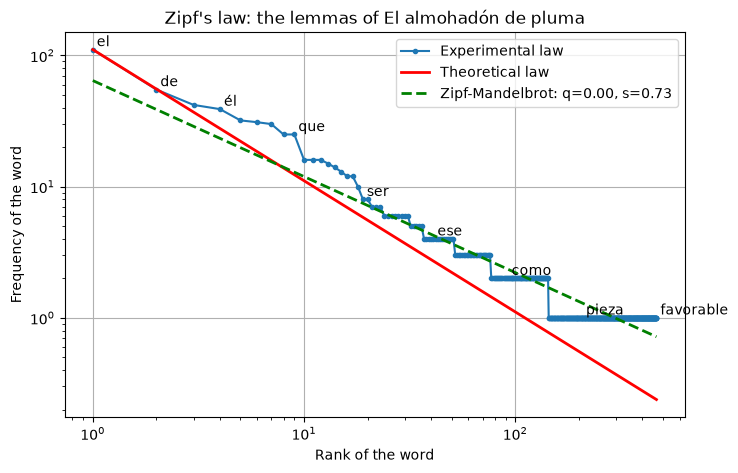

In [20]:
all_lemmas = WordsExtractor(use_lexemes=True, lowercase=True, filter_nums=True).extract(text)
lemma_counts = Counter(all_lemmas)
fit = fit_zipf_mandelbrot(lemma_counts)
print(len(lemma_counts), "lemmas")
print(f"Zipf-Mandelbrot fit: q = {fit.q:.2f}, s = {fit.s:.2f}, R² = {fit.r2:.3f}")
fig, ax = plt.subplots(figsize=(8, 5))
zipf(
    lemma_counts,
    num_labels=10,
    show_theory=True,
    alpha=1.0,
    show_fit=True,
    ax=ax,
    labels={"title": "Zipf's law: the lemmas of El almohadón de pluma"},
)
plt.show()

84 sentences: 14.5 words on average, 64 under 20 words, the longest 44, the shortest 2


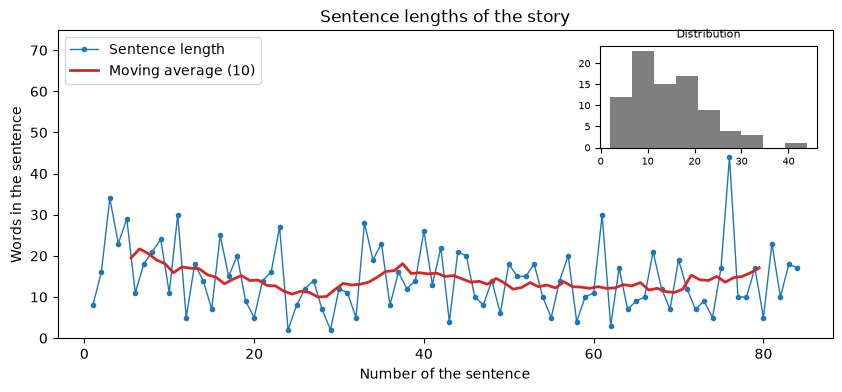

In [21]:
lengths = sentence_lengths(doc)
print(
    f"{len(lengths)} sentences: {sum(lengths) / len(lengths):.1f} words on average, "
    f"{sum(length < 20 for length in lengths)} under 20 words, "
    f"the longest {max(lengths)}, the shortest {min(lengths)}"
)
fig, ax = plt.subplots(figsize=(10, 4))
sentence_lengths_plot(doc, window=10, ax=ax, labels={"title": "Sentence lengths of the story"})
plt.show()

The article `el` heads the 466 lemmas with more than 100 occurrences, and function words (`de`, `él`, `que`) fill the head of the list. The Zipf-Mandelbrot fit has no shift (q = 0.00) and a slope s = 0.73, flatter than the theoretical law with α = 1 (R² = 0.907): past the first ranks the frequencies stay above the theoretical line, and the lemmas seen once form the long flat tail from about rank 150 to 466. The 84 sentences of the `Doc`, two fewer than by `SentsExtractor` since the parser draws the boundaries, alternate between 2 and 44 words, 64 of them under 20; the moving average stays between about 10 and 22 words, with the highest values at the opening.

## Corpus measures

A [KWIC concordance](https://sergeyshk.github.io/esTS/corpus/kwic/) shows every occurrence of a word with its context; by lemma it finds the plural as well. [`collocations`](https://sergeyshk.github.io/esTS/corpus/collocations/) finds the pairs of lemmas that occur together more often than chance would give, by logDice; the lemmas are the ones of the extraction section, without the stop words.

In [22]:
print_kwic(kwic(doc, "almohadón", by_lemma=True, window=6), width=40)
display(pd.DataFrame(collocations(lemmas, window=3, min_freq=3)).round(2))
print_kwic(kwic(doc, "mirar la alfombra", by_lemma=True, window=5), width=35)

             ni aún que le arreglaran el  almohadón    . Sus terrores crepusculares avanzaron e
           ya, miró un rato extrañada el  almohadón    . --Señor--llamó a Jordán en voz
              Jordán en voz baja.--En el  almohadón    hay manchas que parecen de sangre
si imperceptible. La remoción diaria del  almohadón    había impedido sin duda su desarrollo
             no es raro hallarlos en los  almohadones  de pluma


,left,right,freq_left,freq_right,freq_pair,score
0,mirar,alfombra,10,5,4,11.51
1,mirar,rato,10,7,3,10.91
2,cama,mirar,8,10,3,10.83
3,noche,alicia,6,16,3,10.54
4,alicia,mirar,16,10,3,10.30
5,mirar,jordán,10,16,3,10.30


suradamente abiertos, no hacía sino  mirar la alfombra  a uno y otro lado
           de espanto, sin dejar de  mirar la alfombra  . Jordán corrió al dormitorio, y
       Alicia lo miró con extravío,  miró la alfombra   , volvió a mirarlo, y después


The pillow of the title appears only five times: once during the illness (`ni aún que le arreglaran el almohadón`), three times after the death of Alicia, when the servant finds the stains and the narrator explains them, and in the plural in the closing sentence. In a text of 1216 words only six pairs of lemmas occur three times or more within three words of each other, and five of them hold `mirar`: the strongest pair is `mirar` - `alfombra` (4 times, logDice 11.51). The concordance of the phrase shows the three times Alicia stares at the carpet during her illness.

## spaCy components

The [components](https://sergeyshk.github.io/esTS/components/) put the statistics into extensions of the `Doc`, so a pipeline computes them for every document it processes. A pipeline of its own is loaded here, without the named entities that no statistic needs; the readability component reuses the object of the basic statistics (`basic`) instead of counting the text again. `nlp.pipe` then processes all 18 stories of the book, and the table gathers the chosen statistics, sorted by the reading ease.

In [23]:
pipeline = spacy.load("es_core_news_sm", exclude=["ner"])
pipeline.add_pipe("ests_basic", name="basic")
pipeline.add_pipe("ests_readability", name="readability", config={"basic": "basic"})
pipeline.add_pipe("ests_diversity", name="diversity")
pipeline.add_pipe("ests_syntax", name="syntax")
pipeline.add_pipe("ests_lexical", name="lexical")
print(pipeline.pipe_names)
rows = [
    {
        "story": title,
        "words": story._.basic.n_words,
        "words per sentence": story._.basic.n_words / story._.basic.n_sents,
        "syllables per word": story._.basic.n_syllables / story._.basic.n_words,
        "reading ease": story._.readability.flesch_reading_easy,
        "level": story._.readability.describe_level(),
        "MATTR": story._.diversity.mattr,
        "dependency distance": story._.syntax.mean_dependency_distance,
        "beyond top 10000": story._.lexical.p_beyond_top10000,
    }
    for story, title in pipeline.pipe(
        ((body, title) for title, body in stories.items()), as_tuples=True
    )
]
pd.DataFrame(rows).set_index("story").sort_values("reading ease").round(2)

['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'basic', 'readability', 'diversity', 'syntax', 'lexical']


,words,words per sentence,syllables per word,reading ease,level,MATTR,dependency distance,beyond top 10000
story,,,,,,,,
Yaguaí,3503,22.03,2.00,60.45,normal,0.83,2.67,0.10
Los mensú,3382,19.33,2.02,61.73,normal,0.85,2.64,0.10
El infierno artificial,2485,17.88,2.01,63.68,normal,0.83,2.91,0.07
Nuestro primer cigarro,2760,17.92,2.01,63.88,normal,0.84,2.74,0.08
El almohadon de pluma,1216,14.48,2.05,64.43,normal,0.83,2.37,0.09
La miel silvestre,1706,16.56,2.01,64.76,normal,0.83,2.48,0.08
El alambre de pua,3363,16.40,2.01,64.98,normal,0.81,2.58,0.09
La gallina degollada,2389,16.36,2.00,65.82,bastante fácil,0.84,2.54,0.06
Los pescadores de vigas,1941,15.53,2.01,66.23,bastante fácil,0.83,2.55,0.10


The reading ease of the stories runs from 60.45 (*Yaguaí*, the longest sentences, 22.03 words) to 77.42 (*Los ojos sombríos*, the shortest words, 1.88 syllables); seven stories are `normal` and eleven `bastante fácil`. *El almohadón de pluma* is the fifth hardest (64.43): its sentences are shorter than in most stories (14.48 words), but its words are the longest of the book (2.05 syllables per word). Its value differs from the 64.77 of the readability section because the `Doc` takes its 84 sentences from the parser. MATTR hardly varies (0.81-0.85), and the dependency distance of the story, 2.37, is the third shortest, tied with *A la deriva*, after *Los buques suicidantes* (2.25) and *El solitario* (2.29).

## Summary

*El almohadón de pluma* is a short and plain text by its numbers: 1216 words in sentences of 14.14 words, a reading ease of 64.77 (`normal`), a consensus grade of ESO, a mean dependency distance of 2.37 words and almost no passive. What makes it harder are the words: they are the longest of the eighteen stories of the book, 8.9% of them have a lemma beyond the 10000 most frequent ones, and the rare ones name the illness and the animal. The narration runs in the preterite and the imperfect of the indicative, around two names and the verb `mirar`, whose strongest collocate is `alfombra`. The tools also show their limits on this text: a dash glued to a period joins two sentences, the small model reads pronominal verbs as passives, and a sonnet with a third tercet gets no form.